### State Schema With DataClasses
When we define a LangGraph StateGraph, we use a state schema.
-The state schema represents the structure and types of data that our graph will use.

-All nodes are expected to communicate with that schema.
LangGraph offers flexibility in how you define your state schema, accommodating various Python types and validation approaches!


 we can use the TypedDict class from python's typing module.
It allows you to specify keys and their corresponding value types.

But, note that these are type hints.

They can be used by static type checkers (like mypy) or IDEs to catch potential type-related errors before the code is run.
But they are not enforced at runtime!

In [1]:
from sqlalchemy import literal
from streamlit import development
from typing_extensions import TypedDict
from typing import Literal

class TypedDictState(TypedDict):
    """Configuration for the application."""
    name: str       ## does not inforce to string, it can change to int during runtime 
    game: Literal["chess", "cricket"]

In [2]:
def play_game(state: TypedDictState):
    "play a game based on the state"
    # print(f"------ Play game node has been called with game: {state['game']}")
    return {"name": state['name'] + " want to play"}

def cricket(state: TypedDictState):
    # print(f"------ Cricket node has been called with game: {state['game']}")
    return {"game": "cricket"}

def chess(state: TypedDictState):
    # print(f"------ Chess node has been called with game: {state['game']}")
    return {"game": "chess"}

In [3]:

from random import random

def decide_game(state: TypedDictState) -> Literal["chess", "cricket"]:
    # print(f"------ Decide game node has been called with game: {state['game']}")
    if random() < 0.5:
        return "chess"
    elif state['game'] == "cricket":
        return "cricket"

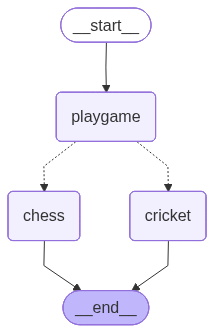

In [4]:
from IPython.display import display, Image
from langgraph.graph import StateGraph, START, END

builder = StateGraph(TypedDictState)
builder.add_node("playgame", play_game)
builder.add_node("cricket", cricket)
builder.add_node("chess", chess)

## Flow of the graph
builder.add_edge(START, "playgame")
builder.add_conditional_edges("playgame", decide_game)
builder.add_edge("cricket", END)
builder.add_edge("chess", END)

# Add
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [5]:
graph.invoke({"name": "Alice"})

KeyError: 'game'

### Dataclasses
Python's dataclasses provide another way to define structured data.

Dataclasses offer a concise syntax for creating classes that are primarily used to store data.

In [6]:
from dataclasses import dataclass

@dataclass
class DataClassState:
    """Configuration for the application."""
    name: str      ## also does not inforce to string, it can change to int during runtime 
    game: Literal["chess", "cricket"]



In [7]:
def play_game(state: DataClassState):
    "play a game based on the state"
    # print(f"------ Play game node has been called with game: {state.game}")
    return {"name": state.name + " want to play"}

def cricket(state: DataClassState):
    # print(f"------ Cricket node has been called with game: {state.game}")
    return {"name": state.name + " cricket", "game":"cricket"}

def chess(state: DataClassState):
    # print(f"------ Chess node has been called with game: {state.game}")
    return {"name": state.name + " chess", "game":"chess"}

In [8]:
def decide_game(state: DataClassState) -> Literal["chess", "cricket"]:
    # print(f"------ Decide game node has been called with game: {state['game']}")
    if random() < 0.5:
        return "chess"
    elif state.game == "cricket":
        return "cricket"

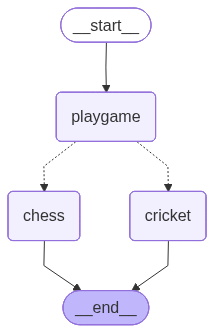

In [9]:
from IPython.display import display, Image
from langgraph.graph import StateGraph, START, END

builder = StateGraph(DataClassState)
builder.add_node("playgame", play_game)
builder.add_node("cricket", cricket)
builder.add_node("chess", chess)

## Flow of the graph
builder.add_edge(START, "playgame")
builder.add_conditional_edges("playgame", decide_game)
builder.add_edge("cricket", END)
builder.add_edge("chess", END)

# Add
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [10]:
graph.invoke(DataClassState(name="Alice", game="cricket"))  ## calling different than TypedDict

{'name': 'Alice want to play chess', 'game': 'chess'}